<a href="https://colab.research.google.com/github/sid2904/cs666student/blob/main/CS666_Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

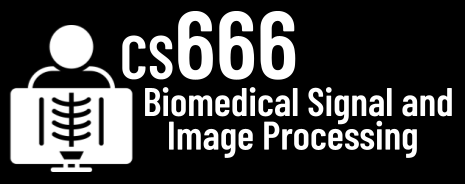
#Assignment 4

In [ ]:
# NAME: Siddhant Setia

In [ ]:
# In this assignment, we will create a Random Forest classifier to detect pneumonia and covid in xrays!

In [ ]:
# load numpy and matplotlib
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [ ]:
# we are using mahotas again, so lets install it!
!pip install mahotas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 63.1 MB/s eta 0:00:00


In [ ]:
# our imports include sklearn this time
import mahotas as mh
import os
from sklearn.ensemble import RandomForestClassifier

**Task 1:** Download, extract, and load the data! [15 Points]

In [ ]:
# Please download this file: https://cs666.org/data/xray/ with the wget command!
# Note: Please use the forwarded dropbox link and change dl=0 to dl=1!
# This is a subset of the Kaggle Pneumonia + Covid Datasets!

In [ ]:
!wget "https://www.dropbox.com/scl/fi/sso8jwvfhoxqarp4zd3fb/xray.zip?rlkey=rvjqu3yj6gmw3r7gmst4ke9fl&e=1&dl=1" -O "xray.zip"

--2026-04-15 14:40:55--  https://www.dropbox.com/scl/fi/sso8jwvfhoxqarp4zd3fb/xray.zip?rlkey=rvjqu3yj6gmw3r7gmst4ke9fl&e=1&dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.6.18, 2620:100:601c:18::a27d:612
Connecting to www.dropbox.com (www.dropbox.com)|162.125.6.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uca3ee6b6522d79f7eb6f32bceb7.dl.dropboxusercontent.com/cd/0/inline/C-pdsE3EYJZQYHPfs8Lkngs_Nnd2KoiOaKaU3Az8SK4p5NKtz8rG76aPymLljb9t79ecNdtLm4Ney8axM1jG-JyPMPgumhOH4lw04QTbdSDC4TAqSlWTaqr3bmbNhD0cBRk/file?dl=1# [following]
--2026-04-15 14:40:56--  https://uca3ee6b6522d79f7eb6f32bceb7.dl.dropboxusercontent.com/cd/0/inline/C-pdsE3EYJZQYHPfs8Lkngs_Nnd2KoiOaKaU3Az8SK4p5NKtz8rG76aPymLljb9t79ecNdtLm4Ney8axM1jG-JyPMPgumhOH4lw04QTbdSDC4TAqSlWTaqr3bmbNhD0cBRk/file?dl=1
Resolving uca3ee6b6522d79f7eb6f32bceb7.dl.dropboxusercontent.com (uca3ee6b6522d79f7eb6f32bceb7.dl.dropboxusercontent.com)... 162.125.6.15, 2620:100:601c:15::a27d:60f
Connec

In [ ]:
# Run this code to extract the zip file and to create
# the folder structure of normal/, pneumonia/, and covid/ images.
# Each folder contains the first images of the Kaggle datasets.
import zipfile
with zipfile.ZipFile('xray.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

NORMAL_DIR = 'normal/'
PNEUMONIA_DIR = 'pneumonia/'
COVID_DIR = 'covid/'

In [ ]:
# Here we load the first image from the normal dataset.
img = mh.imread(NORMAL_DIR + 'IM-0115-0001.jpeg')

In [ ]:
# TODO: Please display this image and print the dimensions!

In [ ]:
# TODO: YOUR CODE

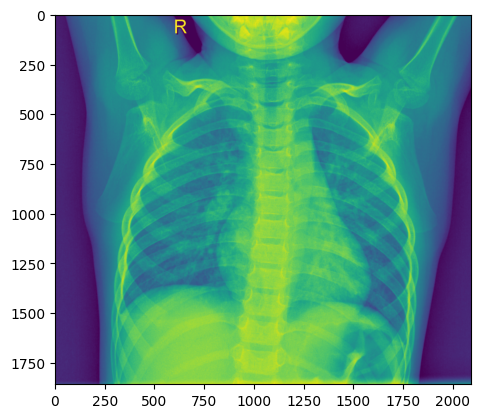

In [ ]:
plt.imshow(img)

In [ ]:
print(img.shape)

(1858, 2090)


**Task 2:** Let's do some data wrangling and more visualization! [30 Points]

In [ ]:
folders = [NORMAL_DIR, PNEUMONIA_DIR, COVID_DIR]
data = [[],[],[]]

for f_index,f in enumerate( folders ):
  all_files = os.listdir( f )

  data[f_index] = np.zeros( (len(all_files), 300, 300), dtype=np.float32)

  for i in range(len(all_files)):
    loaded_image = mh.imread( f + '/' + all_files[i] )
    if loaded_image.ndim > 2:
      loaded_image = mh.colors.rgb2gray(loaded_image[:,:,:3])

    loaded_image = mh.imresize( loaded_image, (300, 300) )
    img_shape = loaded_image.shape

    data[f_index][ i, 0:img_shape[0], 0:img_shape[1] ] = loaded_image

In [ ]:
# The two code blocks above perform 3 data wrangling operations.
# Which ones?
# Hint: The first two might be more obvious but the third one happens in the
# last line.
# TODO: Operation 1) Images are converted to grayscale if they are RGB
# TODO: Operation 2) Image dimenions are modified to (300, 300)
# TODO: Operation 3) Create "batches" of the image data for ease of use with the random forest model

In [ ]:
# Now, let's look at the first 5 normal_images and the first 5 pneumonia_images.
# TODO: Please visualize multiple images at once.
# Hint: You can use one of the following answers from StackOverflow for this:
# https://stackoverflow.com/questions/41210823/using-plt-imshow-to-display-multiple-images

In [ ]:
# TODO: YOUR CODE

<Figure size 640x480 with 0 Axes>

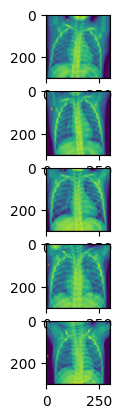

In [ ]:
plt.figure()

f, axarr = plt.subplots(5,1)

axarr[0].imshow(data[0][0])
axarr[1].imshow(data[0][1])
axarr[2].imshow(data[0][2])
axarr[3].imshow(data[0][3])
axarr[4].imshow(data[0][4])

<Figure size 640x480 with 0 Axes>

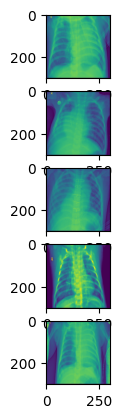

In [ ]:
plt.figure()

f, axarr = plt.subplots(5,1)

axarr[0].imshow(data[1][0])
axarr[1].imshow(data[1][1])
axarr[2].imshow(data[1][2])
axarr[3].imshow(data[1][3])
axarr[4].imshow(data[1][4])

**Task 3:** Setup training and testing data. [15 Points]

In [ ]:
# Any supervised machine learning algorithm requires disjunct sets of
# training and testing data.
#
# For each, we will create a balanced dataset that includes an equal number
# of normal xrays, pneumonia xrays, and covid xrays.
#
# The training data X_train will include 180 images (60 normal, 60 pneumonia, 60 covid).
# The testing data X_test will include the remaining 120 images (40 normal, 40 pneumonia, 40 covid).
#
# Supervised learning means that we tell the algorithm which image is normal
# and which image is pneumonia. For this, we need the y_train vector.
# The vector shall be 0 for a normal image, and 1 for a pneumonia, and 2 for a covid scan.

In [ ]:
TRAINING_COUNT = 60

X_train = np.zeros( (TRAINING_COUNT * 3, 300*300 ), dtype=np.float32)
t_pos = 0

for d in data:
  for image in d[0:TRAINING_COUNT]:
    image = image.ravel() # flatten the image
    image /= image.max() # normalize the image
    X_train[t_pos] = image
    t_pos += 1

In [ ]:
# TODO: Please create the y_train vector with 0 for a normal image,
# 1 for a pneumonia, and 2 for covid. This needs to a numpy array.
y_train = np.repeat([0, 1, 2], TRAINING_COUNT)

In [ ]:
TESTING_COUNT = 40

X_test = np.zeros( (TESTING_COUNT * 3, 300*300 ), dtype=np.float32)
t_pos = 0

for d in data:
  for image in d[TRAINING_COUNT:TRAINING_COUNT+TESTING_COUNT]:
    image = image.ravel() # flatten the image
    image /= image.max() # normalize the image
    X_test[t_pos] = image
    t_pos += 1

In [ ]:
# TODO: Please create the y_test vector with 0 for a normal image,
# 1 for a pneumonia, and 2 for covid. This needs to a numpy array.
y_test = np.repeat([0, 1, 2], TESTING_COUNT)

**Task 4:** Let's train and evaluate the Random Forest! [30 Points]

In [ ]:
# Let's shuffle our training data.
p = np.random.permutation(len(X_train))
X_train = X_train[p]
y_train = y_train[p]

In [ ]:
# With scikit-learn, we can easily set up a default Random Forest classifier.
clf = RandomForestClassifier()

In [ ]:
# Now, we train the classifier with the training data and the training targets.
# We essentially show the classifier an image and tell whether the image is
# normal or pneumonia or covid.
fitted = clf.fit( X_train, y_train )

In [ ]:
# TODO: In just a few sentences, please explain how the Random Forest works.

In [ ]:
# TODO: YOUR ANSWER
# Random forest works by creating multiple decision trees for a subset of the data and taking the average value of all outputs as the final prediction.
# More specifically, a subset of the data is taken by randomly sampling, with replacement, and creating a decision tree for it.
# This process is repeated multiple times to create several decision trees. Then a test data sample is ran on each tree and the average output value is given as the final prediction.

In [ ]:
# After training, we can see how well the classifier predicts our testing data.
# The following command will return the classification accuracy.
clf.score( X_test, y_test )

0.8916666666666667

In [ ]:
# TODO: Is the classification accuracy good? And, are you surprised?

In [ ]:
# TODO: YOUR ANSWER
# No, the accuracy is about 42% which is not good. Yes, this accuracy is surprisingly low considering we have only 3 labels.

**Task 5:** Now, let's decrease the number of trees! [10 Points]

In [ ]:
# How many trees are used in Task 4?

In [ ]:
# TODO: YOUR ANSWER
# The default value of 100 trees were used.

In [ ]:
# Now, please use a single tree and observe the testing performance.

In [ ]:
# TODO: YOUR CODE

In [ ]:
clf_1_tree = RandomForestClassifier(n_estimators=1)
fitted_1_tree = clf_1_tree.fit( X_train, y_train )
clf_1_tree.score( X_test, y_test )

0.8333333333333334

In [ ]:
# Are you surprised?

In [ ]:
# TODO: YOUR ANSWER
# Yes, the performance has increased significantly from 42% to 83%.

**Bonus:** Let's take a closer look! [33 Points]

In [ ]:
# Let's run the fitted classifier on the remaining covid images.
# You might have noticed that there are 199 covid images but we only used 100 so far.
# Please evaluate the classifier on the remaining (previously unseen) 99 covid images
# and check the performance.

In [ ]:
# TODO: YOUR CODE AND YOUR ANSWER

In [ ]:
X_test_covid = np.zeros( ( 99 , 300*300 ), dtype=np.float32)
t_pos = 0

d = data[2]
for image in d[TRAINING_COUNT+TESTING_COUNT:]:
  image = image.ravel() # flatten the image
  image /= image.max() # normalize the image
  X_test_covid[t_pos] = image
  t_pos += 1

y_test_covid = np.repeat([2], 99)

In [ ]:
clf.score( X_test_covid, y_test_covid )

0.9696969696969697

In [ ]:
# Can you figure out which images were misclassified?
# Hint: You can use predictions = clf.predict(X_test_covid_only) for this.
# Can you display them?
# Do you have an idea why these images were problematic?

In [ ]:
# TODO: YOUR CODE AND YOUR ANSWER

In [ ]:
predictions = clf.predict(X_test_covid)
problem_idx = [100+idx for idx in range(len(predictions)) if predictions[idx] != 2]
problem_idx

[132, 140, 185]

In [ ]:
# So, 3 images which are at [132, 140, 185] in the data were misclassified.

<Figure size 640x480 with 0 Axes>

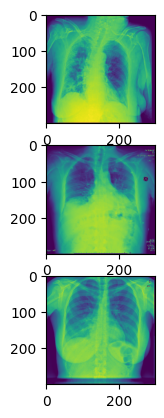

In [ ]:
plt.figure()

f, axarr = plt.subplots(3,1)

axarr[0].imshow(data[2][problem_idx[0]])
axarr[1].imshow(data[2][problem_idx[1]])
axarr[2].imshow(data[2][problem_idx[2]])

In [ ]:
# There are some differences in brightness and contrast between the misclassified images and the correctly classified ones.
# It seems these slight noises in the data are causing issues for the model.

In [ ]:
# Great job!!!
#           ___
#       _.-'   \
#      /        \
#     /          \
#    /            `.___
#   ( .--.)\/(,.--.    `-.
#   ,',-. \   / ,-.`.     )
#  ( /   \     /   \ )   / \
#   || .-|     |-. ||---'|  \
#  _|| | |     | | ||_   |   \
# /. \ |_|.---.|_| / ,\  | .^.\
# `.\ `--"     "--' /,'  |/
#   `>  _________ <'
# ,-' ,---.---.---. `-.
# `--'\    \j/    /`--'
#    `.\         /,'
#      \\_______//
#       `-------'       hjw